Exploratory Data Analysis: Pitchfork
 - explorar el dataset
 

Paso 0: Crear un entorno venv

In [3]:
#Crear un entorno seguro con .venv
!python3 -m venv .venv


1º Cargar las librerias

In [4]:
#Intalar pandas numpy matplotlib scipy seabron pyarrow sklearn (impute, decomposition y neighbors)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pyarrow as pa
import pyarrow.parquet as pq
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier



In [5]:
import os
from pathlib import Path

print("CWD (donde está buscando):", os.getcwd())
print("Archivos en CWD:", os.listdir())


CWD (donde está buscando): c:\Users\juanl\OneDrive\Developer\Python\Pitchfork\notebooks
Archivos en CWD: ['.venv', '01_eda.ipynb', '02_bias_tests.ipynb', '03_rankings.ipynb', 'contenido notebooks.png']


<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 CARGA DE DATOS Y EXPLORACION TIPO DE DATOS:</strong>

In [6]:
#Cargamos el archivo de pitchfork
import pandas as pd

df = pd.read_csv("../reviews.csv")
df.head()


,Unnamed: 0,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year
0,0,22703,mezzanine,massive attack,http://pitchfork.com/reviews/albums/22703-mezz...,9.3,0,nate patrin,contributor,2017-01-08,6,8,1,2017
1,1,22721,prelapsarian,krallice,http://pitchfork.com/reviews/albums/22721-prel...,7.9,0,zoe camp,contributor,2017-01-07,5,7,1,2017
2,2,22659,all of them naturals,uranium club,http://pitchfork.com/reviews/albums/22659-all-...,7.3,0,david glickman,contributor,2017-01-07,5,7,1,2017
3,3,22661,first songs,"kleenex, liliput",http://pitchfork.com/reviews/albums/22661-firs...,9.0,1,jenn pelly,associate reviews editor,2017-01-06,4,6,1,2017
4,4,22725,new start,taso,http://pitchfork.com/reviews/albums/22725-new-...,8.1,0,kevin lozano,tracks coordinator,2017-01-06,4,6,1,2017


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18393 entries, 0 to 18392
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      18393 non-null  int64  
 1   reviewid        18393 non-null  int64  
 2   title           18391 non-null  object 
 3   artist          18391 non-null  object 
 4   url             18393 non-null  object 
 5   score           18393 non-null  float64
 6   best_new_music  18393 non-null  int64  
 7   author          18393 non-null  object 
 8   author_type     14487 non-null  object 
 9   pub_date        18393 non-null  object 
 10  pub_weekday     18393 non-null  int64  
 11  pub_day         18393 non-null  int64  
 12  pub_month       18393 non-null  int64  
 13  pub_year        18393 non-null  int64  
dtypes: float64(1), int64(7), object(6)
memory usage: 2.0+ MB


In [8]:
df.describe()

,Unnamed: 0,reviewid,score,best_new_music,pub_weekday,pub_day,pub_month,pub_year
count,18393.000000,18393.000000,18393.000000,18393.000000,18393.000000,18393.000000,18393.000000,18393.000000
mean,9196.000000,12344.876529,7.005779,0.051270,2.106508,15.529006,6.283532,2008.678465
std,5309.746086,6318.857619,1.293675,0.220553,1.635406,8.757538,3.317349,4.626094
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1999.000000
25%,4598.000000,7445.000000,6.400000,0.000000,1.000000,8.000000,3.000000,2005.000000
50%,9196.000000,12804.000000,7.200000,0.000000,2.000000,15.000000,6.000000,2009.000000
75%,13794.000000,17658.000000,7.800000,0.000000,3.000000,23.000000,9.000000,2013.000000
max,18392.000000,22745.000000,10.000000,1.000000,6.000000,31.000000,12.000000,2017.000000


In [9]:
df.nunique()

Unnamed: 0        18393
reviewid          18389
title             17834
artist             8714
url               18389
score               101
best_new_music        2
author              432
author_type          15
pub_date           3950
pub_weekday           7
pub_day              31
pub_month            12
pub_year             19
dtype: int64

<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 DUPLICADOS:</strong>

In [10]:
#Detectamos duplicados con duplicated().sum() y los mostramos con duplicated()
df.duplicated().sum()


np.int64(0)

In [11]:
# 1. Verificar duplicados solo por reviewid
duplicados_reviewid = df.duplicated(subset=['reviewid']).sum()
print(f"Duplicados por reviewid: {duplicados_reviewid}")

# 2. Si hay duplicados, veamos cuáles son
if duplicados_reviewid > 0:
    # Encontrar las filas con reviewid duplicado
    filas_duplicadas = df[df.duplicated(subset=['reviewid'], keep=False)]
    print(f"\nTotal de filas involucradas: {len(filas_duplicadas)}")
    
    # Mostrar los reviewIDs que se repiten
    reviewids_duplicados = filas_duplicadas['reviewid'].value_counts()
    print("\nReviewIDs que aparecen más de una vez:")
    print(reviewids_duplicados)
    
    # Ver los detalles de esas filas
    print("\n📋 Detalles de las filas con reviewid duplicado:")
    print(filas_duplicadas.sort_values('reviewid')[['reviewid', 'title', 'artist', 'score', 'pub_date', 'author']])
else:
    print("✅ No hay reviewIDs duplicados - Todo correcto!")


Duplicados por reviewid: 4

Total de filas involucradas: 8

ReviewIDs que aparecen más de una vez:
reviewid
9417    2
9505    2
9499    2
9460    2
Name: count, dtype: int64

📋 Detalles de las filas con reviewid duplicado:
       reviewid                         title               artist  score  \
12116      9417                    radiodread  easy star all-stars    7.0   
12120      9417                    radiodread  easy star all-stars    7.0   
12123      9460           subliminal genocide              xasthur    7.8   
12119      9460           subliminal genocide              xasthur    7.8   
12122      9499                young machetes   the blood brothers    6.2   
12118      9499                young machetes   the blood brothers    6.2   
12117      9505  the dfa remixes: chapter two      various artists    8.2   
12121      9505  the dfa remixes: chapter two      various artists    8.2   

         pub_date          author  
12116  2006-10-11     joe tangari  
12120  2006

In [12]:
df.drop_duplicates(subset=['reviewid'], keep='first')
df_limpio = df.drop_duplicates(subset=['reviewid'], keep='first')

In [13]:
# Verificar el número de filas
print(f"Filas finales: {df_limpio.shape[0]}")

# Verificar que reviewid ahora es único
print(f"ReviewIDs únicos: {df_limpio['reviewid'].nunique()}")
print(f"Total de filas: {df_limpio.shape[0]}")

Filas finales: 18389
ReviewIDs únicos: 18389
Total de filas: 18389


<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 NULOS:</strong>

In [14]:
# Ver las filas con nulos en title o artist
filas_con_nulos = df_limpio[(df_limpio['title'].isnull()) | (df_limpio['artist'].isnull())]

print("📋 FILAS CON TITLE O ARTIST NULO:")
print(filas_con_nulos[['reviewid', 'title', 'artist', 'url', 'score', 'author', 'pub_date']])

📋 FILAS CON TITLE O ARTIST NULO:
       reviewid          title   artist  \
3388      19032  konstellaatio      NaN   
3440      18989            NaN      NaN   
11311     10321            NaN  justice   

                                                     url  score  \
3388   http://pitchfork.com/reviews/albums/19032-arti...    7.4   
3440   http://pitchfork.com/reviews/albums/18989-cros...    5.0   
11311  http://pitchfork.com/reviews/albums/10321-just...    8.4   

                     author    pub_date  
3388   grayson haver currin  2014-02-27  
3440              ian cohen  2014-02-12  
11311          jess harvell  2007-06-12  


In [15]:
# Eliminar filas con title o artist nulos
df_limpio = df_limpio.dropna(subset=['title', 'artist'])

# Verificar
nulos_restantes = df_limpio.isnull().sum()
print(f"Filas después de eliminar nulos: {df_limpio.shape[0]}")
print(f"Nulos restantes por columna:\n{nulos_restantes}")

Filas después de eliminar nulos: 18386
Nulos restantes por columna:
Unnamed: 0           0
reviewid             0
title                0
artist               0
url                  0
score                0
best_new_music       0
author               0
author_type       3904
pub_date             0
pub_weekday          0
pub_day              0
pub_month            0
pub_year             0
dtype: int64


<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 METRICAS:</strong>

In [16]:
#Calculamos la media de las puntuaciones
mean_score = df["score"].mean() 
print("Media de las puntuaciones:", mean_score)
#Calculamos mediana de las puntuaciones
median_score = df["score"].median() 
print("Mediana de las puntuaciones:", median_score)
#Calculamos la moda de las puntuaciones
mode_score = df["score"].mode()[0] 
print("Moda de las puntuaciones:", mode_score)



Media de las puntuaciones: 7.005779372587398
Mediana de las puntuaciones: 7.2
Moda de las puntuaciones: 7.0


In [17]:
#Calculamos la desviación estándar de las puntuaciones
std_score = df["score"].std() 
print("Desviación estándar de las puntuaciones:", std_score)

Desviación estándar de las puntuaciones: 1.2936745021540754


In [18]:
#Cual es la puntiuación más alta y más baja
max_score = df["score"].max() 
min_score = df["score"].min() 
print("Puntuación más alta:", max_score)
print("Puntuación más baja:", min_score)
#A que canción corresponde la puntuación más alta y más baja
i_max = df["score"].idxmax()
i_min = df["score"].idxmin()

print("Mejor:", df.loc[i_max, ["artist", "title", "score"]].to_dict())
print("Peor:", df.loc[i_min, ["artist", "title", "score"]].to_dict())


Puntuación más alta: 10.0
Puntuación más baja: 0.0
Mejor: {'artist': 'public image ltd', 'title': 'metal box', 'score': 10.0}
Peor: {'artist': 'various artists', 'title': 'this is next', 'score': 0.0}


In [19]:
#Cuales son las 10 canciones mejor puntuadas
top_10 = df.nlargest(10, "score") 
print("Top 10 canciones mejor puntuadas:") 
print(top_10[["artist", "title", "score"]])
#Cuales son las 10 canciones peor puntuadas
bottom_10 = df.nsmallest(10, "score") 
print("Top 10 canciones peor puntuadas:") 
print(bottom_10[["artist", "title", "score"]])

Top 10 canciones mejor puntuadas:
                     artist                     title  score
191        public image ltd                 metal box   10.0
200               bob dylan       blood on the tracks   10.0
355               brian eno       another green world   10.0
451           stevie wonder  songs in the key of life   10.0
530             nina simone                in concert   10.0
654              neil young       tonight's the night   10.0
706               kate bush            hounds of love   10.0
857                  prince        sign "o" the times   10.0
858                  prince                      1999   10.0
861  prince, the revolution               purple rain   10.0
Top 10 canciones peor puntuadas:
                             artist                      title  score
11067               various artists               this is next    0.0
12155                           jet                   shine on    0.0
13899                robert pollard  relaxation of t

<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 CAMBIOS EN EL DATABASE:</strong>

In [20]:
df.columns


Index(['Unnamed: 0', 'reviewid', 'title', 'artist', 'url', 'score',
       'best_new_music', 'author', 'author_type', 'pub_date', 'pub_weekday',
       'pub_day', 'pub_month', 'pub_year'],
      dtype='object')

In [21]:
#Cambiar el formato de fecha a datetime
df["pub_date"] = pd.to_datetime(df["pub_date"], errors="coerce")
df["pub_date"].head()


0   2017-01-08
1   2017-01-07
2   2017-01-07
3   2017-01-06
4   2017-01-06
Name: pub_date, dtype: datetime64[ns]

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18393 entries, 0 to 18392
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      18393 non-null  int64         
 1   reviewid        18393 non-null  int64         
 2   title           18391 non-null  object        
 3   artist          18391 non-null  object        
 4   url             18393 non-null  object        
 5   score           18393 non-null  float64       
 6   best_new_music  18393 non-null  int64         
 7   author          18393 non-null  object        
 8   author_type     14487 non-null  object        
 9   pub_date        18393 non-null  datetime64[ns]
 10  pub_weekday     18393 non-null  int64         
 11  pub_day         18393 non-null  int64         
 12  pub_month       18393 non-null  int64         
 13  pub_year        18393 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(7), object(5)


In [23]:
print(df.isnull().sum())

Unnamed: 0           0
reviewid             0
title                2
artist               2
url                  0
score                0
best_new_music       0
author               0
author_type       3906
pub_date             0
pub_weekday          0
pub_day              0
pub_month            0
pub_year             0
dtype: int64


<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 ESTO ES PARA VERIFICAR EN QUE PASO ESTAMOS:</strong>
    <ul style="color: black;">

In [24]:



print("="*60)
print("ANÁLISIS DE TU DATASET")
print("="*60)

# 1. Dimensiones
print(f"\n1. DIMENSIONES: {df.shape[0]} filas x {df.shape[1]} columnas")

# 2. Duplicados
duplicados = df_limpio.duplicated().sum()
print(f"\n2. DUPLICADOS: {duplicados}")
if duplicados > 0:
    print("   ⚠️ Necesitas eliminar duplicados")
else:
    print("   ✅ Sin duplicados")

# 3. Nulos
print(f"\n3. VALORES NULOS:")
nulos = df_limpio.isnull().sum()
nulos_con_valores = nulos[nulos > 0]
if len(nulos_con_valores) > 0:
    for col, count in nulos_con_valores.items():
        pct = count/len(df_limpio)*100
        print(f"   - {col}: {count} ({pct:.2f}%)")
else:
    print("   ✅ Sin valores nulos")

# 4. Tipos de datos
print(f"\n4. TIPOS DE DATOS:")
print(df.dtypes)

print("\n" + "="*60)
print("CONCLUSIÓN:")
if duplicados == 0 and len(nulos_con_valores) == 0:
    print("✅ Tu dataset ya está LIMPIO!")
    print("   Puedes pasar directamente a Feature Engineering")
else:
    print("⚠️ Todavía necesitas limpieza:")
    if duplicados > 0:
        print(f"   - Eliminar {duplicados} duplicados")
    if len(nulos_con_valores) > 0:
        print(f"   - Tratar nulos en: {list(nulos_con_valores.index)}")

ANÁLISIS DE TU DATASET

1. DIMENSIONES: 18393 filas x 14 columnas

2. DUPLICADOS: 0
   ✅ Sin duplicados

3. VALORES NULOS:
   - author_type: 3904 (21.23%)

4. TIPOS DE DATOS:
Unnamed: 0                 int64
reviewid                   int64
title                     object
artist                    object
url                       object
score                    float64
best_new_music             int64
author                    object
author_type               object
pub_date          datetime64[ns]
pub_weekday                int64
pub_day                    int64
pub_month                  int64
pub_year                   int64
dtype: object

CONCLUSIÓN:
⚠️ Todavía necesitas limpieza:
   - Tratar nulos en: ['author_type']


<div style="background-color: #E7F1FF; border: 2px solid #0D47A1; padding: 10px; border-radius: 5px; color: black;">
    <strong style="color: #856404;">📌 VISUALIZACIONES:</strong>


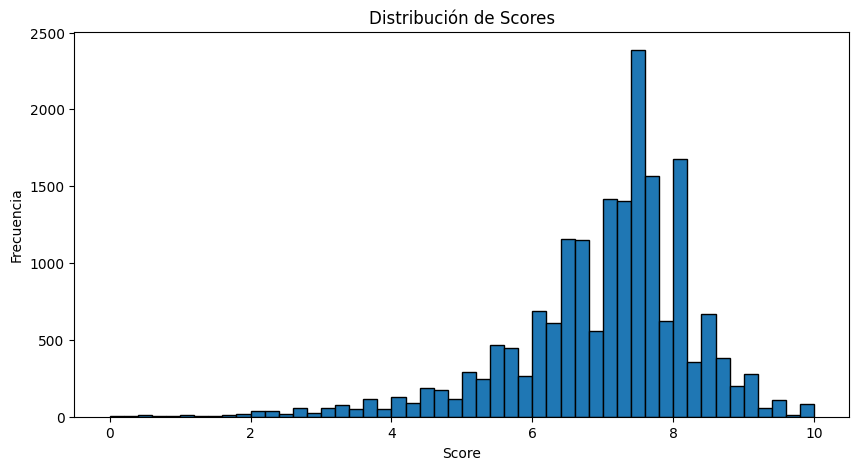

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(df_limpio['score'], bins=50, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Frecuencia')
plt.title('Distribución de Scores')
plt.show()

In [26]:
scores_por_año = df_limpio.groupby('pub_year')['score'].mean()
print(scores_por_año)

pub_year
1999    6.869507
2000    6.791954
2001    7.132675
2002    6.822102
2003    6.940660
2004    7.195629
2005    7.045953
2006    6.977975
2007    6.883374
2008    6.880183
2009    6.820666
2010    6.972650
2011    7.037339
2012    7.012068
2013    7.050167
2014    7.083534
2015    7.106520
2016    7.246087
2017    7.364706
Name: score, dtype: float64


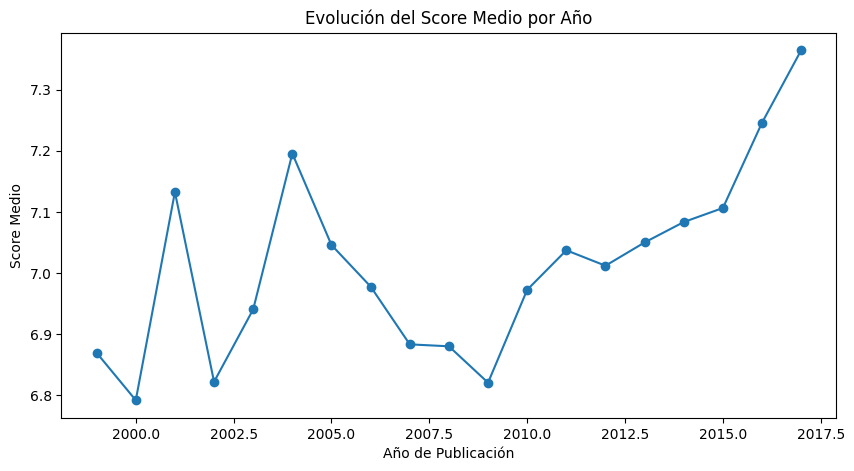

In [27]:
#Representar el score medio por año en un gráfico de líneas
plt.figure(figsize=(10, 5))
plt.plot(scores_por_año.index, scores_por_año.values, marker='o')
plt.xlabel('Año de Publicación')
plt.ylabel('Score Medio')
plt.title('Evolución del Score Medio por Año')
plt.show()

OUTLIERS

In [36]:

#Exploración de outliers con IQR (Interquartile Range), intentamos identificar qué es un outlier en este dataset.
Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)
IQR = Q3 - Q1
FACTOR = 3  # estricto: solo extremos reales

lower_bound = Q1 - FACTOR * IQR
upper_bound = min(Q3 + FACTOR * IQR, 10) # el score no puede superar 10, así que limitamos el upper_bound a 10

print("=" * 45)
print("  CRITERIO: IQR Estricto (factor = 3×IQR)")
print("=" * 45)
print(f"  Q1             : {Q1:.4f}")
print(f"  Q3             : {Q3:.4f}")
print(f"  IQR            : {IQR:.4f}")
print(f"  Límite inferior: {lower_bound:.4f}")
print(f"  Límite superior: {upper_bound:.4f}")
print("=" * 45)

df["is_outlier"]      = (df["score"] < lower_bound) | (df["score"] >= upper_bound)
df["outlier_direction"] = None
df.loc[df["score"] < lower_bound, "outlier_direction"] = "low"
df.loc[df["score"] >= upper_bound, "outlier_direction"] = "high"
n_outliers = df["is_outlier"].sum()
n_low      = (df["outlier_direction"] == "low").sum()
n_high     = (df["outlier_direction"] == "high").sum()

print(f"\nTotal outliers  : {n_outliers:,}  ({n_outliers/len(df)*100:.2f}%)")
print(f"  → Por debajo de {lower_bound:.1f} : {n_low:,}")
print(f"  → Por encima de {upper_bound:.1f}  : {n_high:,}")


  CRITERIO: IQR Estricto (factor = 3×IQR)
  Q1             : 6.4000
  Q3             : 7.8000
  IQR            : 1.4000
  Límite inferior: 2.2000
  Límite superior: 10.0000

Total outliers  : 200  (1.09%)
  → Por debajo de 2.2 : 124
  → Por encima de 10.0  : 76


In [ ]:
#Exploración de outliers con Z-score, intentamos identificar qué es un outlier en este dataset.


In [28]:
# Cuenta reviews extremas
extremas_bajas = df_limpio[df_limpio['score'] < 3].shape[0]
extremas_altas = df_limpio[df_limpio['score'] > 9].shape[0]

print(f"Scores < 3: {extremas_bajas}")
print(f"Scores > 9: {extremas_altas}")

# ¿Qué porcentaje representan?
porcentaje_bajas = (extremas_bajas / len(df_limpio)) * 100
porcentaje_altas = (extremas_altas / len(df_limpio)) * 100

print(f"Porcentaje de scores < 3: {porcentaje_bajas:.2f}%")
print(f"Porcentaje de scores > 9: {porcentaje_altas:.2f}%")

Scores < 3: 245
Scores > 9: 390
Porcentaje de scores < 3: 1.33%
Porcentaje de scores > 9: 2.12%


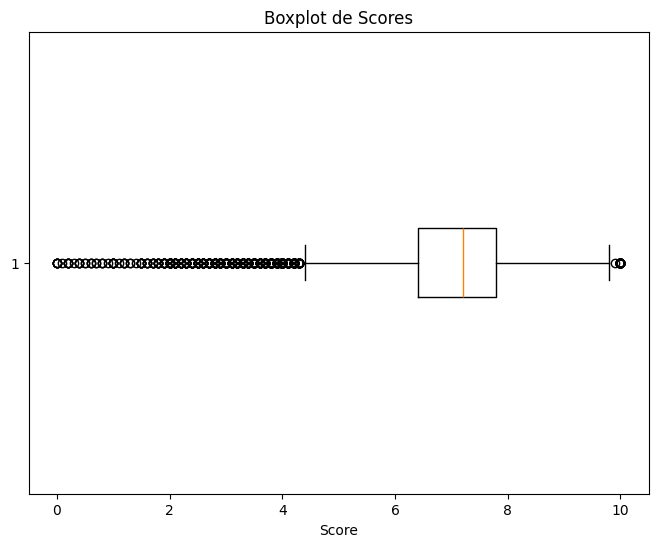

In [29]:
#Boxplot de scores (para ver outliers)
plt.figure(figsize=(8, 6))
plt.boxplot(df_limpio['score'], vert=False)
plt.xlabel('Score')
plt.title('Boxplot de Scores')
plt.show()